# Notebook 04 - Cluster Analysis

This notebook groups countries into clusters based on their cybersecurity profiles using two methods:

1. **KMeans clustering** - partition-based, optimal k selected using the elbow method and silhouette scores
2. **Hierarchical clustering** - agglomerative, visualised as a dendrogram

Clusters are plotted on PCA space (PC1 vs PC2) and interpreted against the CRI theoretical framework. Cluster labels are added to the dataset for use in later notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from IPython.display import display

PROCESSED = '../data/processed/'

df = pd.read_csv(f'{PROCESSED}cleaned_data.csv')
kept_vars = pd.read_csv(f'{PROCESSED}kept_variables.csv')['kept_variables'].tolist()
print(f'Loaded shape: {df.shape}')
print(f'Using variables: {kept_vars}')

Loaded shape: (35, 12)
Using variables: ['ncsi_score', 'gci_capacity', 'gci_cooperation', 'gci_legal', 'gci_organisational', 'gci_technical', 'internet_penetration']


## 1. Standardise Data

Both KMeans and hierarchical clustering are distance-based and require standardised inputs.

In [2]:
X = df[kept_vars].copy()
countries = df['country'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Standardised shape: {X_scaled.shape}')

Standardised shape: (35, 7)


## 2. KMeans - Elbow Method and Silhouette Analysis

We fit KMeans for k = 2 to 10 and use two complementary criteria to select the optimal k:

- **Elbow method:** plot within-cluster sum of squares (inertia) and look for the point where adding clusters gives diminishing returns.
- **Silhouette score:** measures how similar each point is to its own cluster vs. neighbouring clusters. Scores range from -1 to 1; higher is better. This gives a more principled numeric criterion to cross-check the elbow judgment.

  k=2: inertia=149.31
  k=3: inertia=94.21
  k=4: inertia=74.25
  k=5: inertia=64.62
  k=6: inertia=50.96
  k=7: inertia=42.17
  k=8: inertia=35.89
  k=9: inertia=32.11
  k=10: inertia=27.72


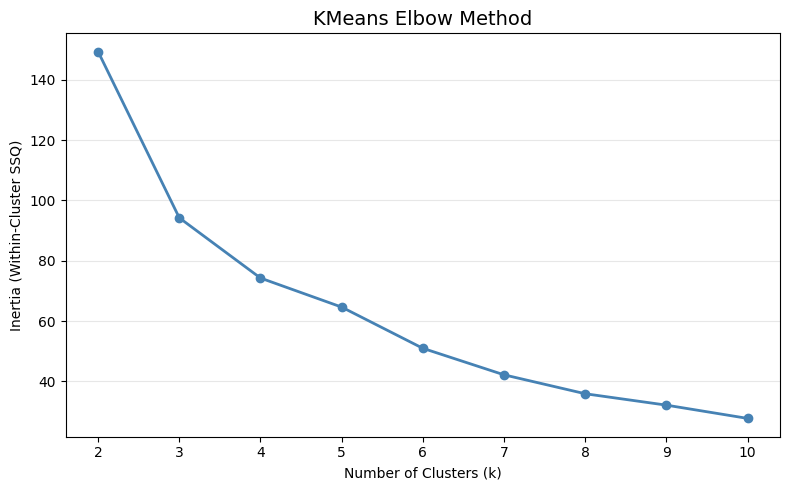

Saved: report/figures/04_elbow_plot.png


In [3]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f'  k={k}: inertia={km.inertia_:.2f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-Cluster SSQ)')
ax.set_title('KMeans Elbow Method', fontsize=14)
ax.set_xticks(list(K_range))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../report/figures/04_elbow_plot.png', dpi=150)
plt.show()
print('Saved: report/figures/04_elbow_plot.png')

  k=2: silhouette=0.7030
  k=3: silhouette=0.4599
  k=4: silhouette=0.3542
  k=5: silhouette=0.2075
  k=6: silhouette=0.2984
  k=7: silhouette=0.3017
  k=8: silhouette=0.2831
  k=9: silhouette=0.2474
  k=10: silhouette=0.2057


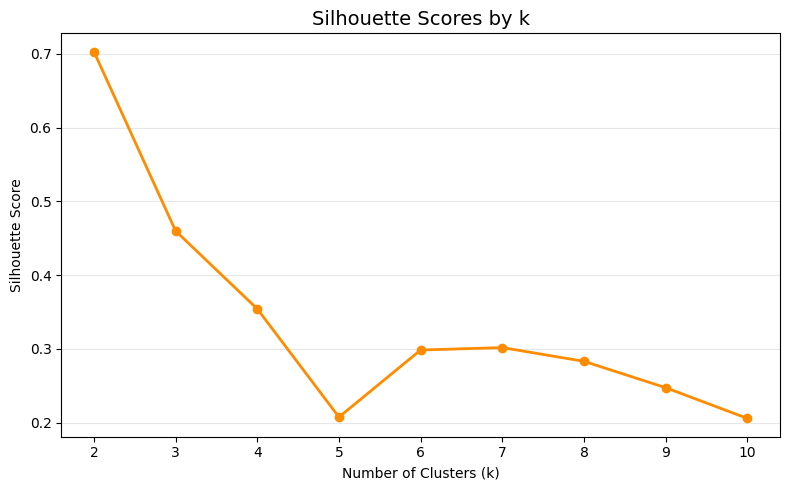

Saved: report/figures/04_silhouette_plot.png

Highest silhouette score at k = 2


In [4]:
silhouette_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f'  k={k}: silhouette={score:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_range), silhouette_scores, marker='o', color='darkorange', linewidth=2)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Scores by k', fontsize=14)
ax.set_xticks(list(K_range))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../report/figures/04_silhouette_plot.png', dpi=150)
plt.show()
print('Saved: report/figures/04_silhouette_plot.png')
print(f'\nHighest silhouette score at k = {K_range[silhouette_scores.index(max(silhouette_scores))]}')

## 3. Apply KMeans with Chosen k

Based on the elbow plot and silhouette scores above, set `OPTIMAL_K` to the value that gives the best balance of low inertia and high silhouette score.

In [5]:
OPTIMAL_K = 4  # Adjust after reviewing the elbow plot and silhouette scores above

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df['cluster_kmeans'] = cluster_labels

print(f'KMeans with k={OPTIMAL_K}:')
print(df.groupby('cluster_kmeans')['country'].apply(list).to_string())

KMeans with k=4:
cluster_kmeans
0    [Australia, Belgium, Brazil, Canada, Denmark, ...
1                                          [Argentina]
2                       [Ghana, India, Kenya, Nigeria]
3    [Austria, China, Czech Republic, Hungary, Isra...


## 4. Hierarchical Clustering - Dendrogram

Hierarchical clustering does not require specifying k in advance. Ward linkage minimises within-cluster variance, which tends to produce compact, similarly sized clusters.

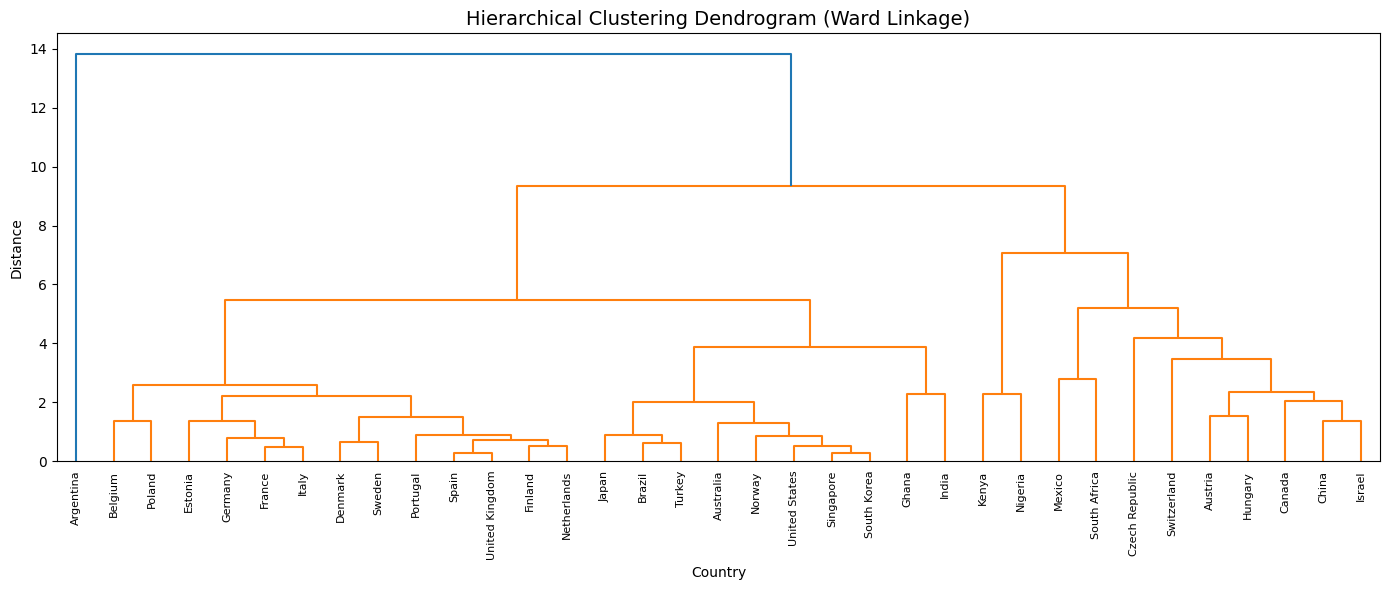

Saved: report/figures/04_dendrogram.png


In [6]:
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    labels=countries,
    orientation='top',
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax
)
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14)
ax.set_xlabel('Country')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig('../report/figures/04_dendrogram.png', dpi=150)
plt.show()
print('Saved: report/figures/04_dendrogram.png')

In [7]:
# Cut the dendrogram at the same k as KMeans for comparison
hier_labels = fcluster(Z, t=OPTIMAL_K, criterion='maxclust')
df['cluster_hierarchical'] = hier_labels

print(f'Hierarchical clusters (k={OPTIMAL_K}):')
print(df.groupby('cluster_hierarchical')['country'].apply(list).to_string())

Hierarchical clusters (k=4):
cluster_hierarchical
1    [Australia, Belgium, Brazil, Denmark, Estonia,...
2                                     [Kenya, Nigeria]
3    [Austria, Canada, China, Czech Republic, Hunga...
4                                          [Argentina]


## 5. Plot Clusters on PCA Space

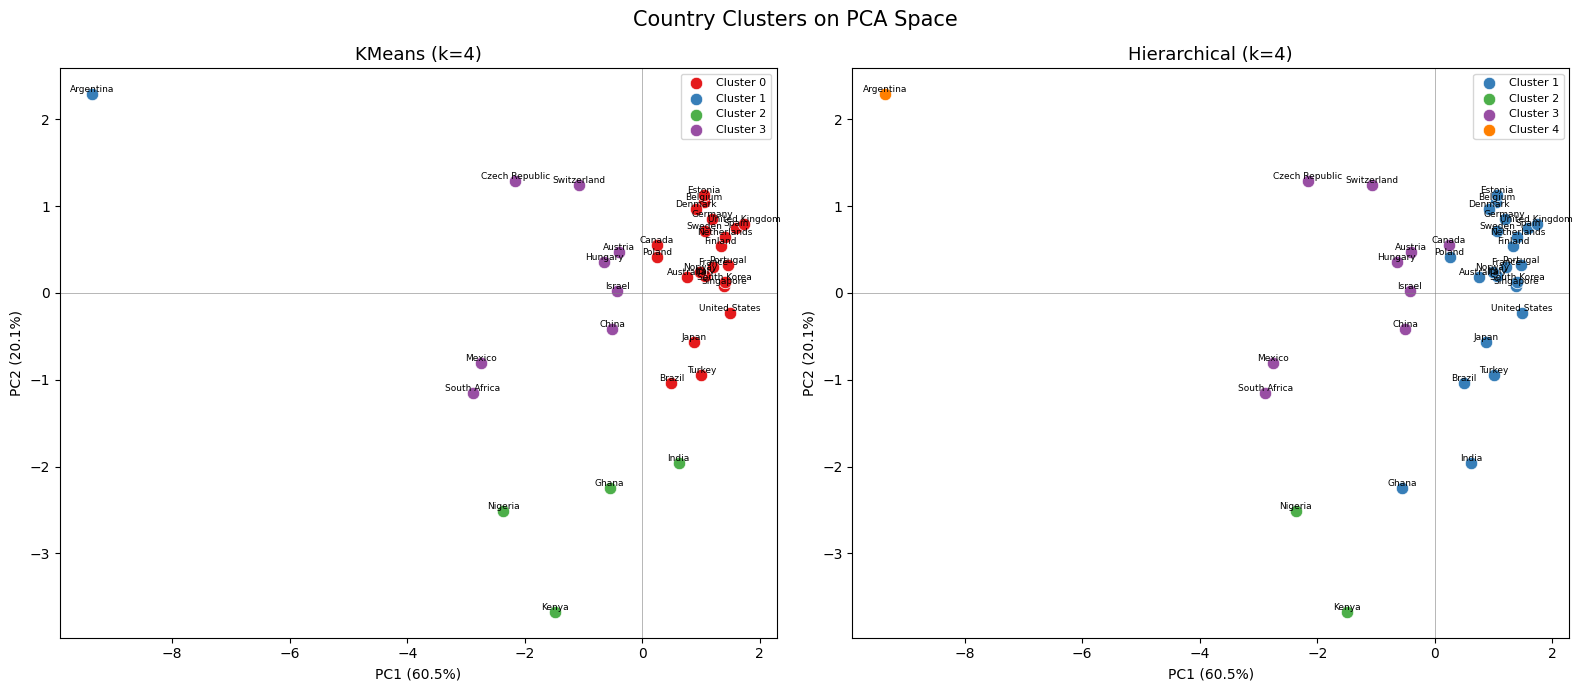

Saved: report/figures/04_cluster_pca.png


In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

palette = plt.cm.Set1.colors
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, label_col, title in [
    (axes[0], 'cluster_kmeans', f'KMeans (k={OPTIMAL_K})'),
    (axes[1], 'cluster_hierarchical', f'Hierarchical (k={OPTIMAL_K})'),
]:
    labels_plot = df[label_col].values
    for cluster_id in sorted(set(labels_plot)):
        mask = labels_plot == cluster_id
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            color=palette[cluster_id % len(palette)],
            label=f'Cluster {cluster_id}',
            s=80, edgecolors='white', linewidths=0.5
        )
        for i, country in enumerate(countries):
            if mask[i]:
                ax.annotate(country, (X_pca[i, 0], X_pca[i, 1]),
                            fontsize=6.5, ha='center', va='bottom')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=8)
    ax.axhline(0, color='grey', linewidth=0.4)
    ax.axvline(0, color='grey', linewidth=0.4)

plt.suptitle('Country Clusters on PCA Space', fontsize=15)
plt.tight_layout()
plt.savefig('../report/figures/04_cluster_pca.png', dpi=150)
plt.show()
print('Saved: report/figures/04_cluster_pca.png')

## 6. Cluster Interpretation

The cluster means table below shows the average value of each indicator variable per cluster. Higher values on GCI pillars and internet penetration indicate stronger cybersecurity capacity.

We then compare the cluster structure to the CRI theoretical framework (four sub-indices: Technical Capacity, Legal and Regulatory, Capacity Building, Organisational Measures) to check whether the data-driven groupings reflect the expected country-level patterns.

=== KMeans Cluster Means (original scale) ===


,ncsi_score,gci_capacity,gci_cooperation,gci_legal,gci_organisational,gci_technical,internet_penetration
cluster_kmeans,,,,,,,
0,77.92,19.58,19.71,19.94,19.19,19.26,92.36
1,63.64,3.14,9.98,14.55,10.19,12.96,89.23
2,46.76,16.86,17.79,19.80,17.87,18.86,50.77
3,62.34,16.79,17.46,18.64,16.83,18.06,88.41


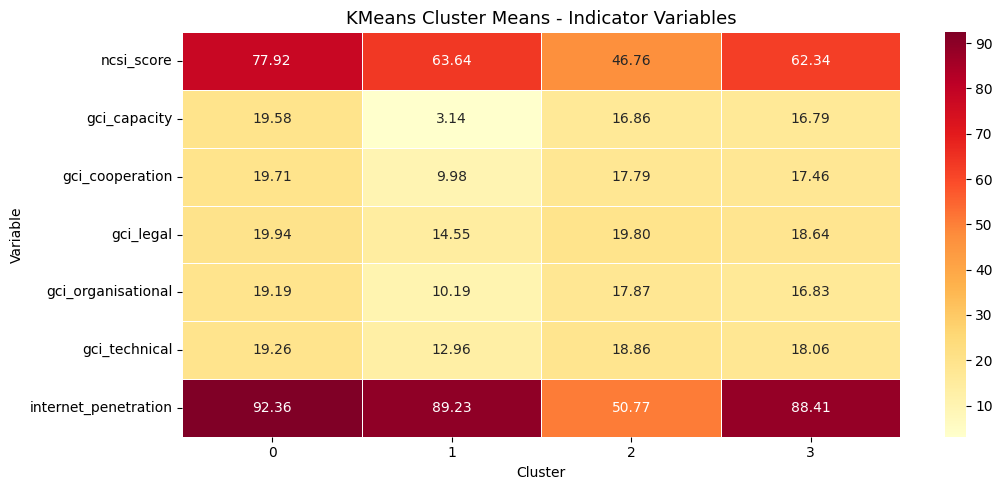

Saved: report/figures/04_cluster_means_heatmap.png


In [9]:
print('=== KMeans Cluster Means (original scale) ===')
cluster_means = df.groupby('cluster_kmeans')[kept_vars].mean().round(2)
display(cluster_means)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    cluster_means.T,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)
ax.set_title('KMeans Cluster Means - Indicator Variables', fontsize=13)
ax.set_xlabel('Cluster')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.savefig('../report/figures/04_cluster_means_heatmap.png', dpi=150)
plt.show()
print('Saved: report/figures/04_cluster_means_heatmap.png')

## 7. Save Dataset with Cluster Labels

### Comparison to Theoretical Framework

The CRI is organised around four sub-indices: Technical Capacity, Legal and Regulatory, Capacity Building, and Organisational Measures. The cluster analysis above is purely data-driven, so it does not have to match that structure exactly.

What we expect to see, based on the theoretical framework:

- A group of high-income countries (e.g. Finland, Estonia, Norway, Singapore) should score consistently high across all four sub-index dimensions.
- A group of upper-middle-income countries (e.g. Poland, Czech Republic, China) should perform well on technical infrastructure but show more variation on the legal and organisational pillars.
- Lower-income countries (e.g. Nigeria, Kenya, Ghana) are likely to cluster together with low scores on all dimensions, particularly internet penetration and GCI technical capacity.
- Argentina confirmed as an outlier -- its GCI pillar scores (capacity, cooperation, organisational) are far below every other country in the dataset, placing it in a singleton cluster in both methods.

If the data-driven clusters broadly reflect these groupings, it provides validation that the CRI sub-indices are capturing real differences in cybersecurity maturity. Significant divergence from this expectation would suggest either measurement issues in the data or that the theoretical framework needs revision.

In [10]:
output_path = f'{PROCESSED}clustered_data.csv'
df.to_csv(output_path, index=False)
print(f'Saved clustered data to {output_path}')
print(f'Shape: {df.shape}')

Saved clustered data to ../data/processed/clustered_data.csv
Shape: (35, 14)
